<a href="https://colab.research.google.com/github/Jayantsinghkhanna/UCS547-ACCELERATED-DATA-SCIENCE-LAB/blob/main/Assignment_5_Accelerated_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTION 1
CPU vs GPU PIPELINE

In [2]:
!pip install -q nvidia-dali-cuda120

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.8/420.8 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 22.9 MB/s eta 0:00:00


In [3]:
import cv2
import os
import glob
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

In [4]:
uploaded = files.upload()

Saving images (6).jpeg to images (6).jpeg
Saving images (5).jpeg to images (5).jpeg
Saving images (4).jpeg to images (4).jpeg
Saving images (3).jpeg to images (3).jpeg
Saving images (2).jpeg to images (2).jpeg
Saving images (1).jpeg to images (1).jpeg
Saving download (7).jpeg to download (7).jpeg
Saving download (6).jpeg to download (6).jpeg
Saving download (5).jpeg to download (5).jpeg
Saving download (4).jpeg to download (4).jpeg
Saving images.jpeg to images.jpeg
Saving download (3).jpeg to download (3).jpeg
Saving download (2).jpeg to download (2).jpeg
Saving download (1).jpeg to download (1).jpeg
Saving download.jpeg to download.jpeg


In [5]:
image_paths = glob.glob("*.jpg") + \
              glob.glob("*.jpeg")

print("Total Images:",
      len(image_paths))

Total Images: 15


In [18]:
# ============================================================
# CPU PIPELINE
# ============================================================

cpu_times = []

start_cpu_total = time.time()

for path in image_paths:

    start = time.time()

    # Load image
    img = cv2.imread(path)

    # Resize image
    resized = cv2.resize(
        img,
        (512,512)
    )

    # Convert to grayscale
    gray = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    cpu_times.append(
        time.time() - start
    )

cpu_total_time = time.time() - start_cpu_total

cpu_avg_time = np.mean(cpu_times)

print("CPU Total Time:",
      round(cpu_total_time,4),
      "seconds")

print("CPU Average Time:",
      round(cpu_avg_time,4),
      "seconds")

CPU Total Time: 0.015 seconds
CPU Average Time: 0.001 seconds


In [20]:
# ============================================================
# GPU PIPELINE USING PYTORCH
# ============================================================
import torch
gpu_times = []

device = torch.device("cuda")

start_gpu_total = time.time()

for path in image_paths:

    start = time.time()

    # Load image
    img = cv2.imread(path)

    # Skip invalid image
    if img is None:
        continue

    # Resize image
    resized = cv2.resize(
        img,
        (512,512)
    )

    # Convert to GPU tensor
    tensor_img = torch.tensor(
        resized,
        device=device,
        dtype=torch.float32
    )

    # Grayscale conversion on GPU
    gray_gpu = torch.mean(
        tensor_img,
        dim=2
    )

    # Synchronize GPU
    torch.cuda.synchronize()

    gpu_times.append(
        time.time() - start
    )

gpu_total_time = time.time() - start_gpu_total

gpu_avg_time = np.mean(gpu_times)

print("GPU Total Time:",
      round(gpu_total_time,4),
      "seconds")

print("GPU Average Time:",
      round(gpu_avg_time,4),
      "seconds")

GPU Total Time: 0.0317 seconds
GPU Average Time: 0.0021 seconds


In [14]:
speedup = cpu_total_time / gpu_total_time

print("GPU Speedup:",
      round(speedup,2),
      "x")

GPU Speedup: 0.59 x


In [22]:
results = pd.DataFrame({

    'Pipeline': ['CPU','GPU'],

    'Total Time': [
        cpu_total_time,
        gpu_total_time
    ],

    'Average Time': [
        cpu_avg_time,
        gpu_avg_time
    ]
})

print(results)

  Pipeline  Total Time  Average Time
0      CPU    0.015035      0.000987
1      GPU    0.031690      0.002095


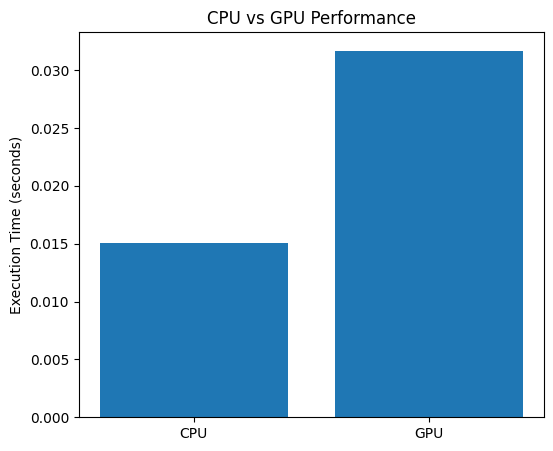

In [23]:
plt.figure(figsize=(6,5))

plt.bar(
    ['CPU','GPU'],
    [cpu_total_time,
     gpu_total_time]
)

plt.ylabel(
    "Execution Time (seconds)"
)

plt.title(
    "CPU vs GPU Performance"
)

plt.show()

GPU-based decoding provides speedup because GPUs perform many image operations simultaneously using parallel processing.

The advantage reduces for small datasets because GPU computation includes:

memory transfer overhead
GPU initialization
synchronization costs

QUESTION 2
GRAYSCALE CONVERSION

In [25]:
image_paths = glob.glob("*.jpg") + \
              glob.glob("*.jpeg")

img = cv2.imread(image_paths[0])

print("Image Shape:",
      img.shape)

Image Shape: (194, 259, 3)


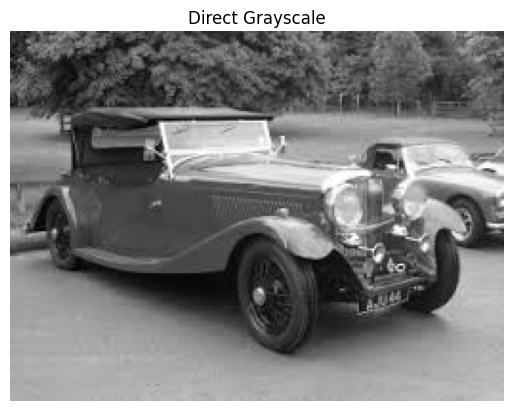

In [26]:
direct_gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

plt.imshow(
    direct_gray,
    cmap='gray'
)

plt.title(
    "Direct Grayscale"
)

plt.axis('off')

plt.show()

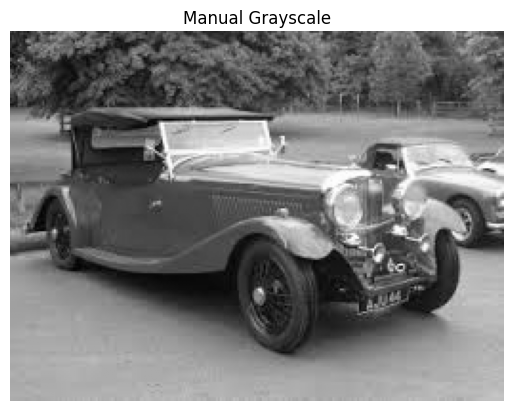

In [27]:
B = img[:,:,0]
G = img[:,:,1]
R = img[:,:,2]

manual_gray = (

    0.299*R +

    0.587*G +

    0.114*B

)

manual_gray = manual_gray.astype(
    np.uint8
)

plt.imshow(
    manual_gray,
    cmap='gray'
)

plt.title(
    "Manual Grayscale"
)

plt.axis('off')

plt.show()

In [28]:
small = cv2.resize(
    img,
    (256,256)
)

large = cv2.resize(
    img,
    (1024,1024)
)

print("Small Resolution:",
      small.shape)

print("Large Resolution:",
      large.shape)

Small Resolution: (256, 256, 3)
Large Resolution: (1024, 1024, 3)


YCbCr is used because human vision is more sensitive to brightness than color.

JPEG compresses chrominance more aggressively while preserving luminance quality.

RGB conversion occurs after IDCT because decompression reconstructs image data in YCbCr format first.

QUESTION 3
HYBRID vs DALI PIPELINE

In [29]:
from nvidia.dali.pipeline import Pipeline

import nvidia.dali.fn as fn

import nvidia.dali.types as types

In [30]:
# ============================================================
# HYBRID PIPELINE
# ============================================================

start_hybrid = time.time()

for path in image_paths:

    # CPU decode
    img = cv2.imread(path)

    # Resize
    resized = cv2.resize(
        img,
        (512,512)
    )

    # Transfer to GPU
    tensor_img = torch.tensor(
        resized,
        device='cuda',
        dtype=torch.float32
    )

    # Normalize
    normalized = tensor_img / 255.0

    torch.cuda.synchronize()

hybrid_time = time.time() - start_hybrid

print("Hybrid Time:",
      round(hybrid_time,4),
      "seconds")

Hybrid Time: 0.0737 seconds


In [36]:
import glob

image_paths = glob.glob("*.jpg") + \
              glob.glob("*.jpeg")

print("Total Images Found:",
      len(image_paths))

print(image_paths[:5])

Total Images Found: 15
['images (1).jpeg', 'images (3).jpeg', 'download.jpeg', 'images (4).jpeg', 'images (6).jpeg']


In [37]:
# ============================================================
# WORKING DALI PIPELINE
# ============================================================

from nvidia.dali.pipeline import Pipeline

import nvidia.dali.fn as fn

import nvidia.dali.types as types

class SimplePipeline(Pipeline):

    def __init__(

        self,

        image_dir,

        batch_size,

        num_threads,

        device_id

    ):

        super().__init__(

            batch_size=batch_size,

            num_threads=num_threads,

            device_id=device_id

        )

        self.input = fn.readers.file(

            files=image_paths,

            random_shuffle=False

        )

    def define_graph(self):

        jpegs, labels = self.input

        images = fn.decoders.image(

            jpegs,

            device='mixed'

        )

        images = fn.resize(

            images,

            resize_x=512,

            resize_y=512

        )

        images = fn.crop_mirror_normalize(

            images,

            dtype=types.FLOAT,

            output_layout='HWC'

        )

        return images

In [38]:
pipe = SimplePipeline(

    image_dir='.',

    batch_size=4,

    num_threads=2,

    device_id=0

)

pipe.build()

start_dali = time.time()

num_batches = len(image_paths) // 4

if num_batches == 0:
    num_batches = 1

for i in range(num_batches):

    pipe.run()

dali_time = time.time() - start_dali

print("DALI Time:",
      round(dali_time,4),
      "seconds")

DALI Time: 0.1128 seconds


In [39]:
hybrid_throughput = \
    len(image_paths) / hybrid_time

dali_throughput = \
    len(image_paths) / dali_time

print(
    "Hybrid Throughput:",
    round(hybrid_throughput,2),
    "images/sec"
)

print(
    "DALI Throughput:",
    round(dali_throughput,2),
    "images/sec"
)

Hybrid Throughput: 203.61 images/sec
DALI Throughput: 133.01 images/sec


In [40]:
comparison = pd.DataFrame({

    'Pipeline': [
        'Hybrid',
        'DALI'
    ],

    'Execution Time': [
        hybrid_time,
        dali_time
    ],

    'Throughput': [
        hybrid_throughput,
        dali_throughput
    ]
})

print(comparison)

  Pipeline  Execution Time  Throughput
0   Hybrid        0.073670  203.611603
1     DALI        0.112778  133.005006


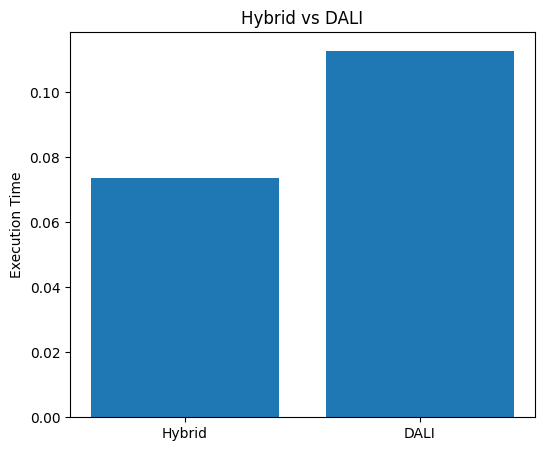

In [42]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Hybrid','DALI'],
    [hybrid_time,dali_time]
)

plt.ylabel(
    "Execution Time"
)

plt.title(
    "Hybrid vs DALI"
)

plt.show()

ALI improves performance because:

decoding
resizing
normalization

all occur directly on GPU memory.

This avoids repeated CPU-GPU transfers and improves pipeline parallelism.

Therefore DALI achieves:

higher throughput
lower latency
better GPU utilization
improved scalability for deep learning workloads.